# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: SREEVINAYAK KALARICKAL SURESH



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [ ]:
## Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib


# 1. Business Understanding
Goal: Predict the price of a house based on certain characteristics of the property such as area, number of bedrooms, bathrooms, stories, and amenities.

# 2. Data Understanding

## 2.1 Load dataset

In [ ]:
## Read *.csv file into pandas DataFrame
df = pd.read_csv(r'C:\DCIM\SG\TP\syllabus\SEM_3\MLDP\Projects\housing.csv')
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


## 2.2 Summary Statistics

In [5]:
## Understand the type of variable for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
## Check for missing data
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [7]:
## Describe data distribution
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

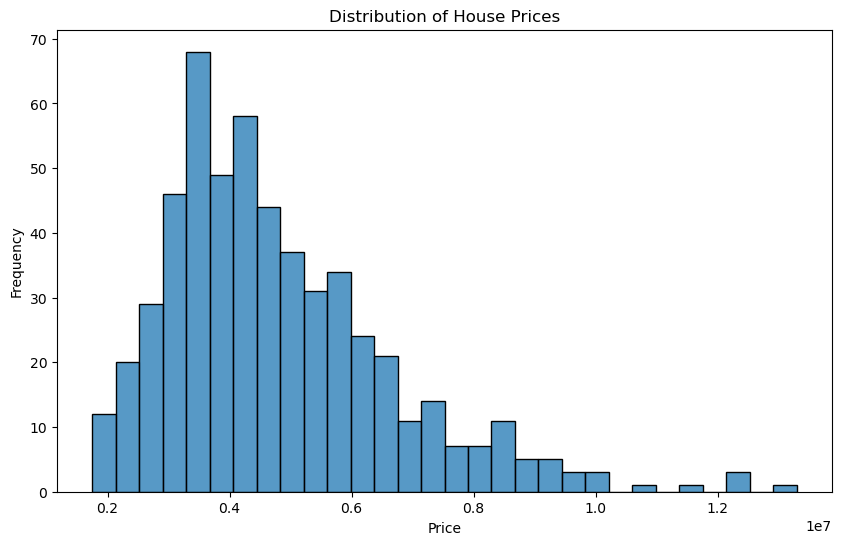

In [8]:
## Understanding distribution of target
plt.figure(figsize=(10,6))
sns.histplot(df['price'], bins=30)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

### 2.3.1.2 Understanding distribution of features

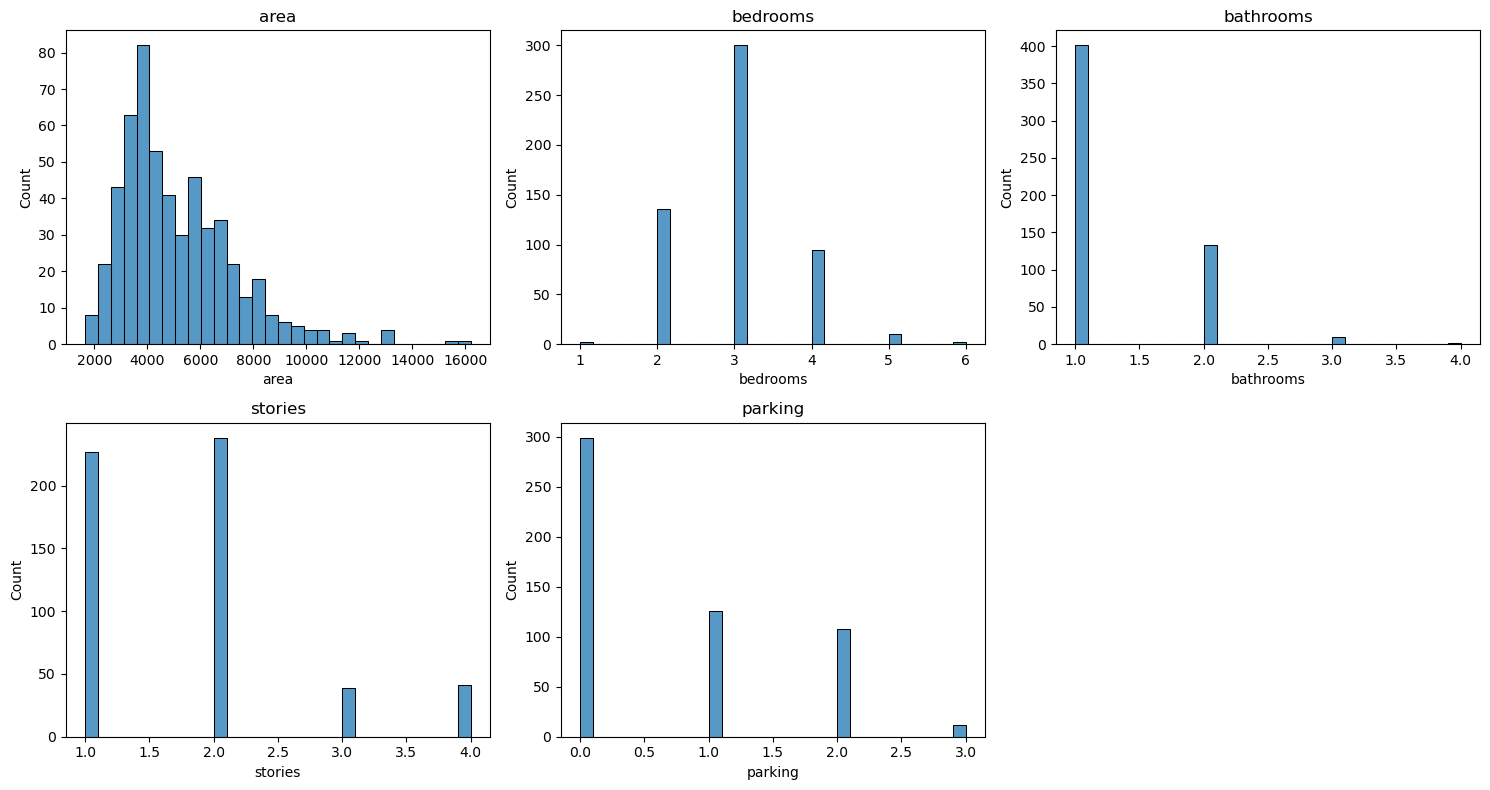

In [9]:
## Understanding distribution of numerical features

numerical_cols = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], bins=30, ax=axes[i])
    axes[i].set_title(f'{col}')

# Remove the empty subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

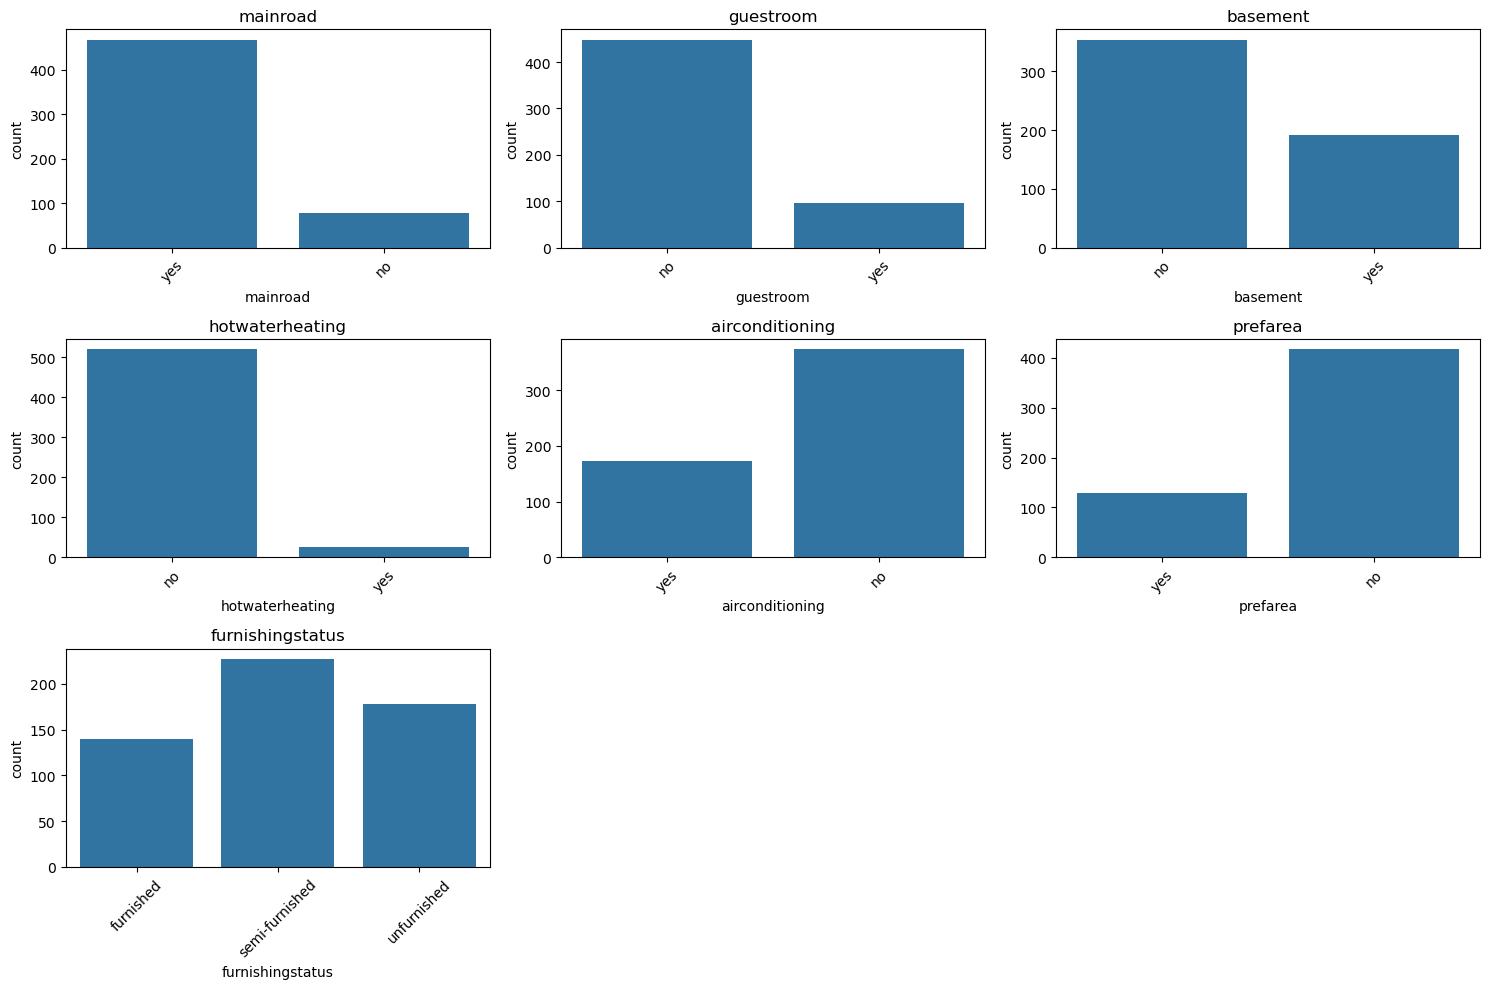

In [10]:
## Understanding distribution of categorical features
categorical_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
                    'airconditioning', 'prefarea', 'furnishingstatus']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'{col}')
    axes[i].tick_params(axis='x', rotation=45)

# Remove unused subplots
for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 2.3.2 Understanding relationship between variables

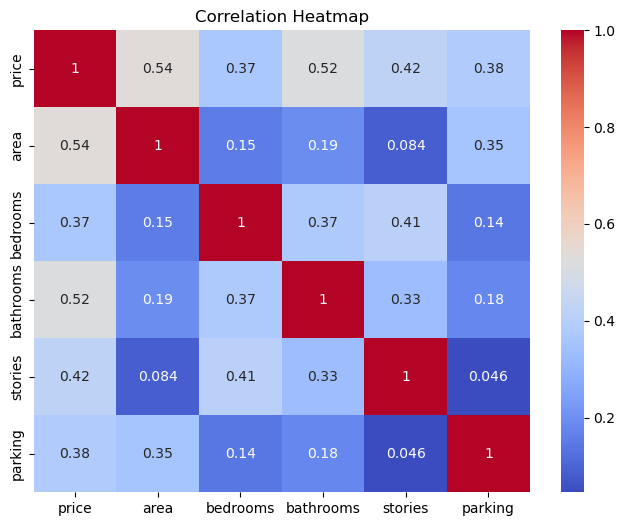

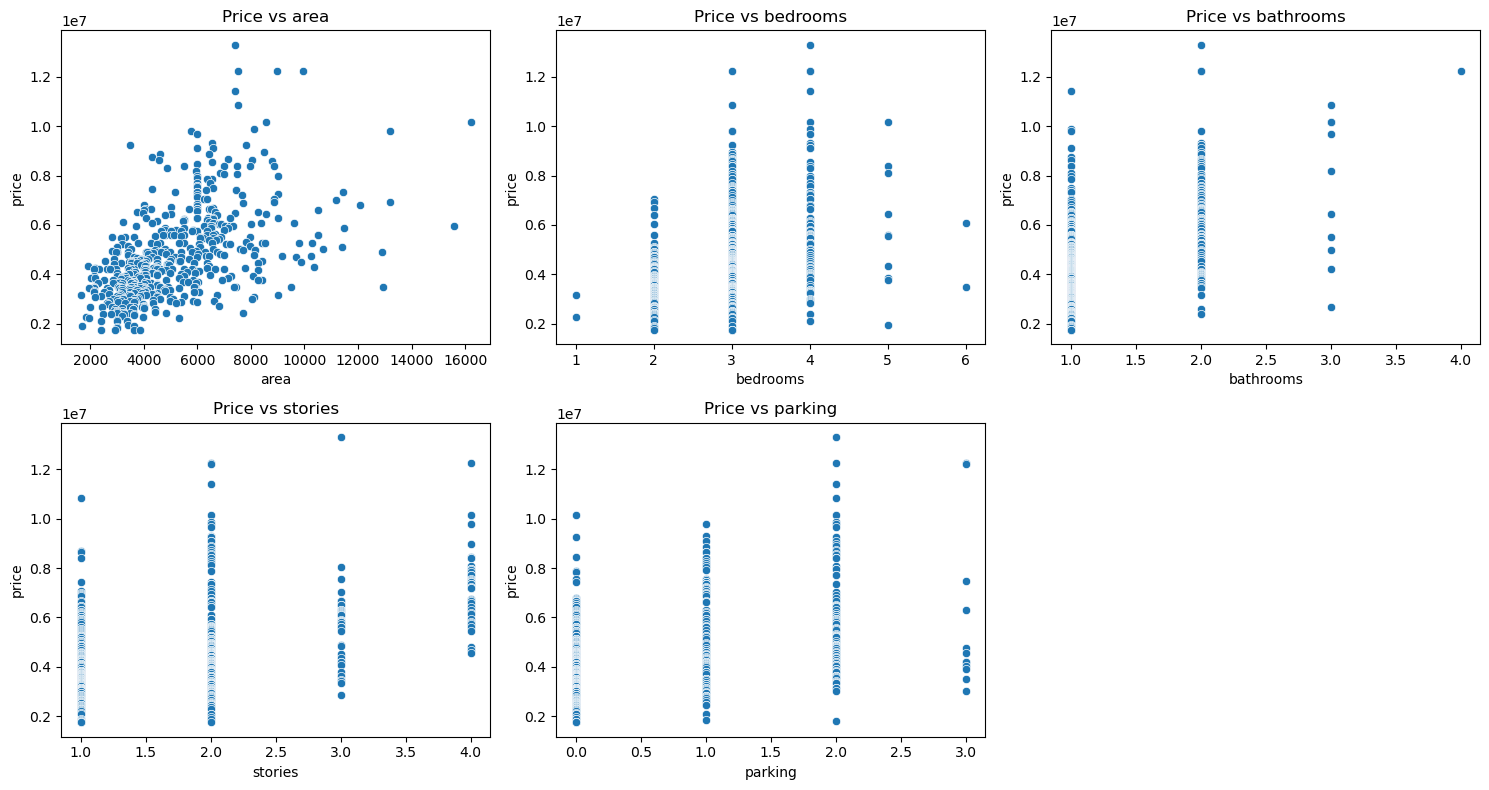

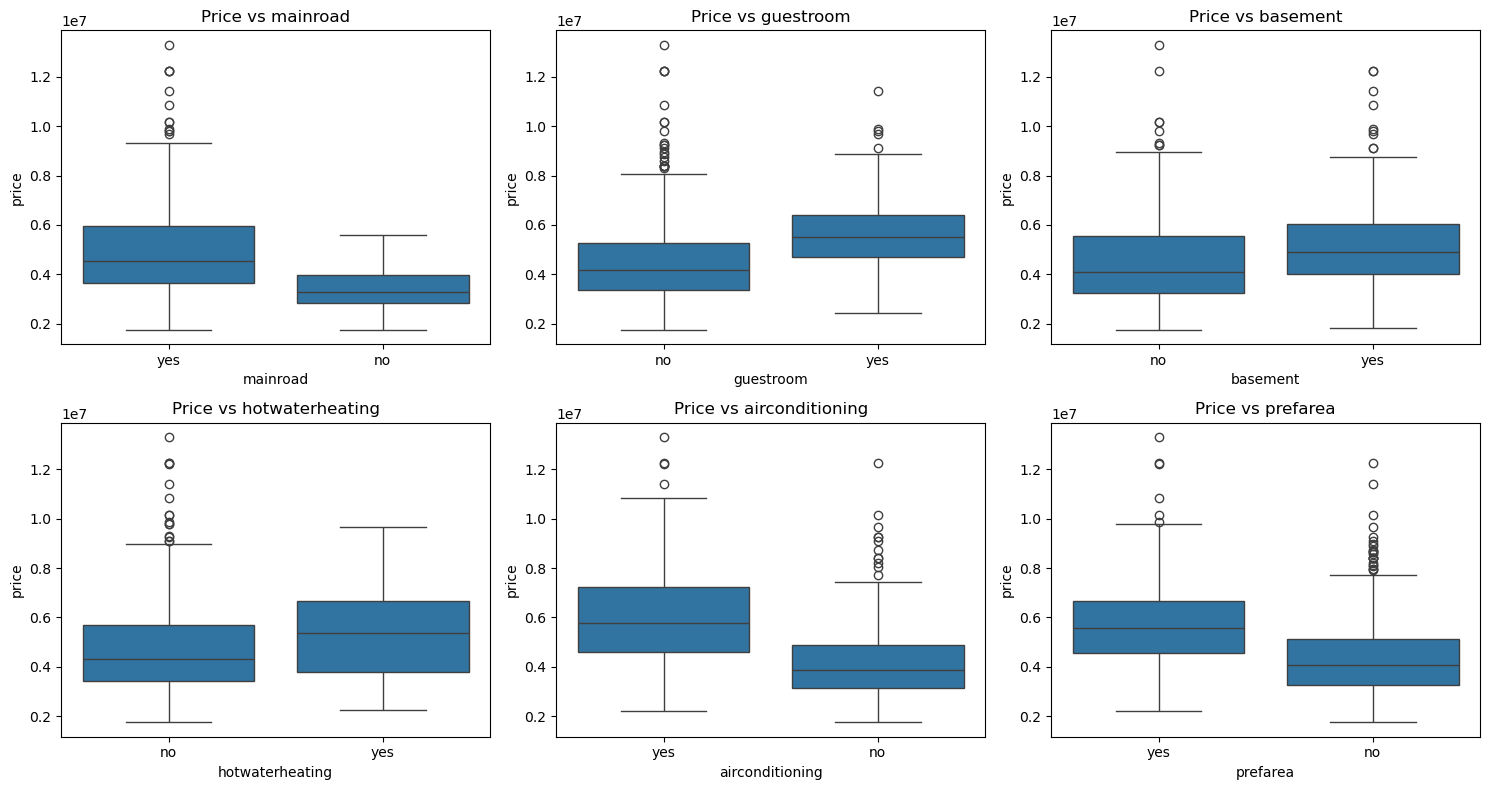

In [11]:
## Understanding relationship between variables
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


#scatter Plots(Numerical Features vs Price)
numerical_cols = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

fig, axes = plt.subplots(2, 3, figsize=(15,8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.scatterplot(data=df, x=col, y='price', ax=axes[i])
    axes[i].set_title(f'Price vs {col}')
# Remove empty subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()


#box Plots(Categorical Features vs Price)
categorical_cols = ['mainroad', 'guestroom', 'basement',
                    'hotwaterheating', 'airconditioning', 'prefarea']

fig, axes = plt.subplots(2, 3, figsize=(15,8))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.boxplot(data=df, x=col, y='price', ax=axes[i])
    axes[i].set_title(f'Price vs {col}')

plt.tight_layout()
plt.show()

# 3. Data Preparation

## 3.1 Data Cleaning

In [12]:
#clean data
from sklearn.preprocessing import LabelEncoder, StandardScaler

#create a copy of the dataset
df_clean = df.copy()

#check for missing values
print(df_clean.isnull().sum())

#encode binary categorical variables
binary_cols = ['mainroad', 'guestroom', 'basement',
               'hotwaterheating', 'airconditioning', 'prefarea']

encoder = LabelEncoder()

for col in binary_cols:
    df_clean[col] = encoder.fit_transform(df_clean[col])

#one-hot encode furnishing status
df_clean = pd.get_dummies(df_clean, columns=['furnishingstatus'])

#scale numerical features
numerical_cols = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

scaler = StandardScaler()
df_clean[numerical_cols] = scaler.fit_transform(df_clean[numerical_cols])

#display cleaned data
print(df_clean.head())
print("Shape:", df_clean.shape)

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64
      price      area  bedrooms  bathrooms   stories  mainroad  guestroom  \
0  13300000  1.046726  1.403419   1.421812  1.378217         1          0   
1  12250000  1.757010  1.403419   5.405809  2.532024         1          0   
2  12250000  2.218232  0.047278   1.421812  0.224410         1          0   
3  12215000  1.083624  1.403419   1.421812  0.224410         1          0   
4  11410000  1.046726  1.403419  -0.570187  0.224410         1          1   

   basement  hotwaterheating  airconditioning   parking  prefarea  \
0         0                0                1  1.517692         1   
1         0                0                1  2.679409         0   
2         1                0   

## 3.2 Train-Test Split

In [13]:
# Train-Test Split

from sklearn.model_selection import train_test_split

# Separate features and target
X = df_clean.drop('price', axis=1)
y = df_clean['price']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Display the shapes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (436, 14)
X_test: (109, 14)
y_train: (436,)
y_test: (109,)


# 4. Modelling

### 4.2 Train Model

In [14]:
# Hyperparameter Tuning
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score

#parameter grid
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

#random forest model
rf = RandomForestRegressor(random_state=42)

#randomized Search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    random_state=42
)

#train model
random_search.fit(X_train, y_train)

best_rf = random_search.best_estimator_

#predict on test set
y_pred = best_rf.predict(X_test)

#display results
print("Best Parameters:", random_search.best_params_)
print("R² Score:", r2_score(y_test, y_pred))

Best Parameters: {'n_estimators': 100, 'min_samples_split': 10, 'max_depth': 30}
R² Score: 0.5855283872406621


# 5. Model Evaluation

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train and Evaluate Models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "R² Score": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
    })

#display results
comparison_df = pd.DataFrame(results)
print(comparison_df)

best_model = comparison_df.loc[comparison_df["R² Score"].idxmax()]
print("\nBest Model:", best_model["Model"])
print("R² Score:", best_model["R² Score"])

               Model  R² Score           MAE          RMSE
0  Linear Regression  0.652924  9.700434e+05  1.324507e+06
1      Decision Tree  0.406959  1.280133e+06  1.731349e+06
2      Random Forest  0.611878  1.018052e+06  1.400639e+06

Best Model: Linear Regression
R² Score: 0.6529242642153176


In [16]:
## Predict on New Data

new_data = pd.DataFrame({
    'area': [8500],
    'bedrooms': [4],
    'bathrooms': [3],
    'stories': [2],
    'mainroad': [1],
    'guestroom': [1],
    'basement': [1],
    'hotwaterheating': [0],
    'airconditioning': [1],
    'parking': [2],
    'prefarea': [1],
    'furnishingstatus_furnished': [1],
    'furnishingstatus_semi-furnished': [0],
    'furnishingstatus_unfurnished': [0]
})

# Predict house price
prediction = best_rf.predict(new_data)

print("Predicted House Price:", prediction[0])

Predicted House Price: 9938097.039992232


## Iterative model development


In [20]:
## Further feature engineering / feature selection
import joblib
import streamlit as st

# Save the trained model
joblib.dump(best_rf, "house_price_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model saved successfully!")

Model saved successfully!
